In [1]:
# Cell 1 — Imports & load
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from quality_utils import analyze_noisy

DATA_PATH = "../data/vehicle_positions_week.csv"
OUTPUT_DIR = "quality_report"

df = pl.read_csv(
    DATA_PATH,
    try_parse_dates=True,
    schema_overrides={
        "ort_nr_start_vvo": pl.Utf8,
        "ort_nr_ziel_vvo": pl.Utf8,
    }
)
print(f"总行数: {len(df):,}")

总行数: 10,972,462


In [2]:
# Cell 2 — Run analysis
result = analyze_noisy(df, output_dir=OUTPUT_DIR)

labels = {
    "n1_gps_zero":           "N1 GPS zero",
    "n2_distanz_spike":      "N2 distanz spike",
    "n3_distanz_small_drop": "N3 small drop",
    "n4_lage_extreme":       "N4 lage extreme",
    "n5_lage_default_zero":  "N5 lage default 0",
    "n6_bad_status":         "N6 bad status",
}

for key, label in labels.items():
    r = result[key]
    print(f"{label:25s}: {r['count']:>8,}  ({r['rate']:.4%})")

print(f"\n{'Union (any noisy)':25s}: "
      f"{result['noisy_union_count']:>8,}  "
      f"({result['noisy_union_rate']:.4%})")

N1 GPS zero              :       83  (0.0008%)
N2 distanz spike         :   31,609  (0.2881%)
N3 small drop            :   87,415  (0.7967%)
N4 lage extreme          :   63,732  (0.5808%)
N5 lage default 0        :  266,788  (2.4314%)
N6 bad status            :  199,225  (1.8157%)

Union (any noisy)        :  266,788  (2.4314%)


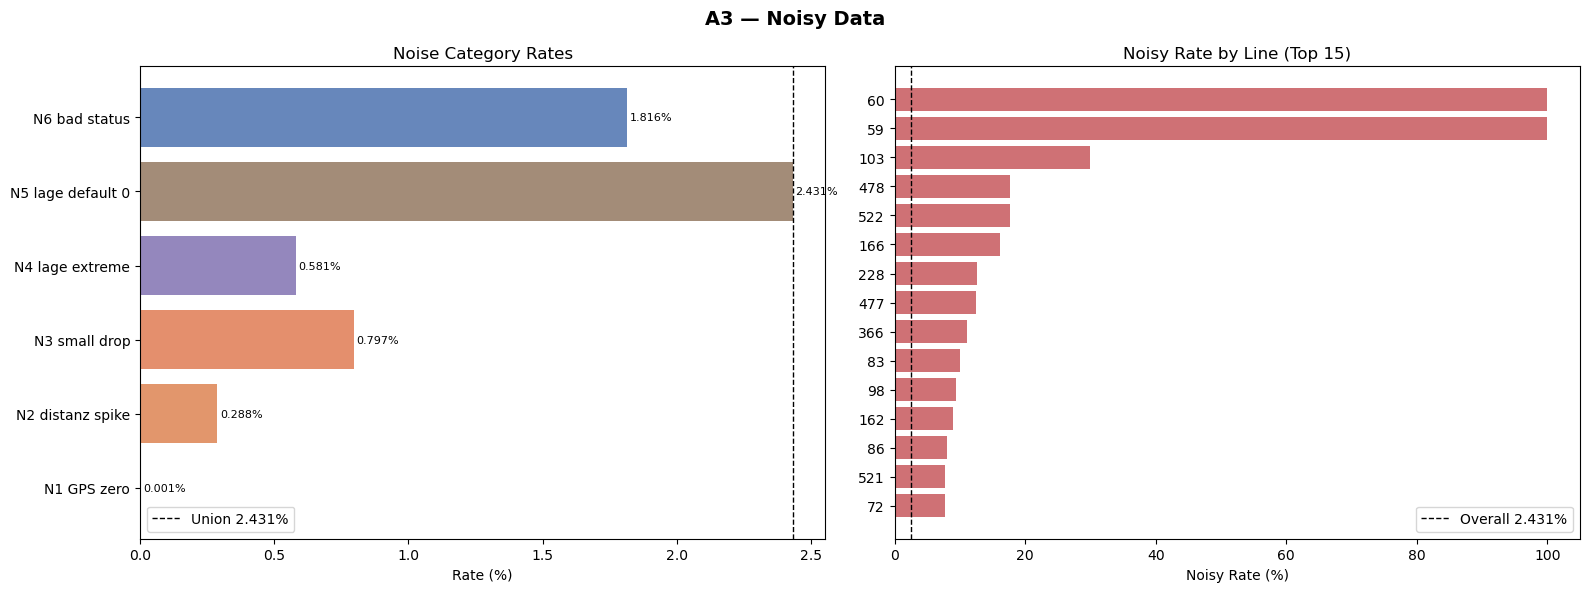

In [3]:
# Cell 3 — Visualization
categories = list(labels.values())
counts = [result[k]["count"] for k in labels]
rates  = [result[k]["rate"] * 100 for k in labels]

by_line = pl.from_dicts(result["noisy_by_line"]).sort("noisy_rate", descending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("A3 — Noisy Data", fontsize=14, fontweight="bold")

# Left: per-category rates
ax = axes[0]
colors = ["#C44E52", "#DD8452", "#E07B54", "#8172B2", "#937860", "#4C72B0"]
bars = ax.barh(categories, rates, color=colors, alpha=0.85)
ax.set_xlabel("Rate (%)")
ax.set_title("Noise Category Rates")
for bar, rate in zip(bars, rates):
    if rate > 0:
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{rate:.3f}%", va="center", fontsize=8)
ax.axvline(result["noisy_union_rate"] * 100, color="black",
           linestyle="--", linewidth=1,
           label=f"Union {result['noisy_union_rate']:.3%}")
ax.legend()

# Right: per-line noisy rate (top 15)
ax2 = axes[1]
plot_df = by_line.head(15).sort("noisy_rate")
line_labels = [str(x) for x in plot_df["linie"].to_list()]
line_rates  = [x * 100 for x in plot_df["noisy_rate"].to_list()]
ax2.barh(line_labels, line_rates, color="#C44E52", alpha=0.8)
ax2.set_xlabel("Noisy Rate (%)")
ax2.set_title("Noisy Rate by Line (Top 15)")
ax2.axvline(result["noisy_union_rate"] * 100, color="black",
            linestyle="--", linewidth=1,
            label=f"Overall {result['noisy_union_rate']:.3%}")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/A3_noisy.png", dpi=150, bbox_inches="tight")
plt.show()